**This code use Distilbert model for Feminisms datasets (CgatGPT-generated data, AND Falcon-generated dataset) with three main experiments:**


1.   **Experiment1**: train the model using original dataset and test it on original set
2.   **Experiment2**: train the model using synthetic dataset and test it on original set then synth set
3.   **Experiment3**: train the model using merge dataset and test it on original set




In [1]:
!pip install torch
!pip install transformers
!pip install pandas
!pip install emoji

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 52.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 23.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 100.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.9/358.9 kB 4.8 MB/s eta 0:00:00


In [2]:
# Import Basics
import pandas as pd
import numpy as np
import string
import emoji
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.utils import shuffle
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import shuffle
from sklearn.metrics import f1_score


In [3]:
#Select the dataset to train the model

#Experiment1:
#selected_train_dataset='Real_train_feminism_664.csv' #original trainig set
#selected_test_dataset='Real_test_feminism_285.csv'  #original testing set

#Experiment2:
#for ChatGPT data:
#selected_train_dataset='ChatGPT_synth_train_feminism_664.csv' #ChatGPT's generated data (training set)
#selected_test_dataset='Real_test_feminism_285.csv'  #original testing set
#selected_ChatGPT_test_dataset='ChatGPT_synth_test_feminism_285.csv'  #ChatGPT's generated data (testing set)
#for Falcon data:
selected_train_dataset='FALCON_femin_train_664.csv'           #Falcon's  generated data (training set)
selected_test_dataset='Real_test_feminism_285.csv'  #original testing set
selected_Falcon_test_dataset='FALCON_femin_test_285.csv'            #Falcon's  generated data (testing set)

#Experiment3:
#for ChatGPT merge
#selected_train_dataset='ChatGPT_merge_feminism_1329.csv'      #ChatGPT's generated data merge with original training set
#selected_test_dataset='Real_test_feminism_285.csv'  #original testing set
#for Falcon data
#selected_train_dataset='FALCON_merge_femin_1329.csv'          #Falcon's generated data merge with original training set
#selected_test_dataset='Real_test_feminism_285.csv'  #original testing set


For the sake of simplicity, we will present one experiment, as all other experiments follow the same steps with changes in the dataset. However, we will present the results of each experiment.

**The following presents the main steps for each experiment:**

#1. Load the datasets

In [4]:
traindf = pd.read_csv(selected_train_dataset)

In [5]:
testdf = pd.read_csv(selected_test_dataset)

In [6]:
testdf_synth= pd.read_csv(selected_Falcon_test_dataset) #for Experiment2 to test on synthetic data

In [7]:
traindf.head()

,Tweet,Stance
0,#GenderPayGap - #EqualPay - it is time we get ...,FAVOR
1,"Feminism isn't a dirty word, it's a call to ac...",FAVOR
2,"""Feminism is just a woman's way of destroying ...",AGAINST
3,"""@womenslibuk: Men should be allowed the same ...",AGAINST
4,Women should not be judged for the choices the...,FAVOR


In [7]:
# mapping the labels
mapping = {'NONE': 0, 'FAVOR': 1, 'AGAINST': 2}
traindf['Stance'] = traindf['Stance'].apply(lambda x: mapping[x])
traindf.head()

,Tweet,Stance
0,#GenderPayGap - #EqualPay - it is time we get ...,1
1,"Feminism isn't a dirty word, it's a call to ac...",1
2,"""Feminism is just a woman's way of destroying ...",2
3,"""@womenslibuk: Men should be allowed the same ...",2
4,Women should not be judged for the choices the...,1


In [8]:
testdf['Stance'] = testdf['Stance'].apply(lambda x: mapping[x])

In [9]:
testdf_synth['Stance']= testdf_synth['Stance'].apply(lambda x: mapping[x]) #for Experiment2 to map the labels of synth testset

#2. Visualizing the dataset

In [11]:
traindf['Stance'].value_counts()

2    328
1    210
0    126
Name: Stance, dtype: int64

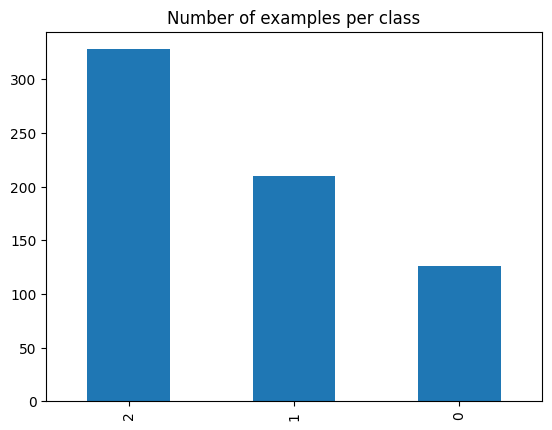

In [12]:
traindf['Stance'].value_counts().sort_values(ascending=False).plot(kind="bar")
plt.title("Number of examples per class");

In [13]:
traindf.shape,  testdf.shape,

((664, 2), (285, 4))

In [14]:
 testdf_synth.shape #(for expr2)

(285, 2)

#3. Data Pre-processing

In [10]:
#clean the tweets
def preprocess(datatw):
    text = datatw.lower()  # convert to lowercase
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)  # remove URLs
    text = re.sub(r"@\w+", "<USERNAME>", text)  # normalize usernames
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    text = emoji.demojize(text)  # remove emojis
    text = re.sub(r"(:[\w\d]+:)", "", text)  # remove emoji codes
    text = re.sub(r"\s+", " ", text).strip()  # remove extra whitespace

    return text

In [11]:
# apply preprocessing
traindf['Tweet'] = traindf['Tweet'].apply(preprocess)

In [17]:
traindf.head()

,Tweet,Stance
0,genderpaygap equalpay it is time we get the sa...,1
1,feminism isnt a dirty word its a call to actio...,1
2,feminism is just a womans way of destroying al...,2
3,USERNAME men should be allowed the same rights...,2
4,women should not be judged for the choices the...,1


In [12]:
testdf['Tweet'] = testdf['Tweet'].apply(preprocess)

In [13]:
testdf_synth['Tweet'] = testdf_synth['Tweet'].apply(preprocess) # for Experiment3 to clean the synthetic testset

In [14]:
# creat cutom dataset to preparing tweet data for training

class Tweet_Dataset(Dataset):

  #class instance initalization (load the data)
    def __init__(self, data, tokenizer, max_length):
        self.tokenizer = tokenizer
        self.texts = data['Tweet'].tolist()
        self.labels = data['Stance'].tolist()
        self.max_length = max_length

   #return the length of the dataset
    def __len__(self):
        return len(self.texts)

   #getting the elements
    def __getitem__(self, index):
        text = str(self.texts[index])
        label = self.labels[index]
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
         #return token IDs, attention mask for actual content, and labels
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


#4. Train the model

In [15]:
# set the tokenizer and model parameters
pretrained_model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# define the model function to use it for each fold
def create_model():
    model = AutoModelForSequenceClassification.from_pretrained(pretrained_model_name, num_labels=3)
    model.to(device)
    return model

In [16]:
#set training parameters
batch_size = 16
learning_rate = 1e-05 # across (1e-03, 1e-04, 1e-05), 1e-03 was the best for all three experiments
num_epochs=10         # across (5, 10, 15), 10 was the best for Experemint1,2 BUT 15 is best for Exper3 with merge data

# initialize the cross-validation
num_folds = 5
cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)


In [ ]:
#Train the model

accuracy_ = []
f1_score_ = []

#cross-validation for 5 folds
for fold, (train_texts, val_texts) in enumerate(cv.split(traindf, traindf['Stance'])):

    #split the dataset into train and validation sets
    train_fold = traindf.iloc[train_texts]
    val_fold = traindf.iloc[val_texts]

    #create data loader for train and valedation set
    train_dataset = Tweet_Dataset(train_fold, tokenizer, max_length=128)
    val_dataset = Tweet_Dataset(val_fold, tokenizer, max_length=128)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    model = create_model()

    optim = AdamW(model.parameters(), lr=learning_rate)
    criterion = torch.nn.CrossEntropyLoss()

    #training for each epoch in this fold
    for epoch in range(num_epochs):
        model.train()
        trainloss = 0.0
        totaldata = 0
        correct_prediction = 0

        for batch in train_loader:
            optim.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            logits = outputs.logits
            #calculate predicted labels
            _, predicted_labels = torch.max(logits, dim=1)
            correct_prediction += (predicted_labels == labels).sum().item()#for accuracy
            totaldata += labels.size(0)

            loss = criterion(logits, labels)
            trainloss += loss.item()

            loss.backward()
            optim.step()

        train_accuracy = correct_prediction / totaldata
        trainloss /= len(train_loader)

        print(f"Fold: {fold+1}/{num_folds} - Epoch: {epoch+1}/{num_epochs}")
        print(f"Train Loss: {trainloss:.4f} - Train Accuracy: {train_accuracy:.4f}")

    # evaluate the model for each fold
    model.eval()
    valloss = 0.0
    total_data = 0
    correct_prediction = 0
    predicted_list_label = []
    true_list_label = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            _, predicted_labels = torch.max(logits, dim=1)
            correct_prediction += (predicted_labels == labels).sum().item()
            total_data += labels.size(0)
            #compute val loss
            valloss += criterion(logits, labels).item()

            predicted_list_label.extend(predicted_labels.cpu().numpy())
            true_list_label.extend(labels.cpu().numpy())

    #calculate val loss, as well as accuracy and F1 score and append them to lists
    valloss /= len(val_loader)
    val_accuracy = correct_prediction / total_data
    val_f1_score = f1_score(true_list_label, predicted_list_label, average='weighted')
    f1_score_.append(val_f1_score)
    accuracy_.append(val_accuracy)

# average metrics across all folds
average_accuracy = sum(accuracy_) / num_folds
average_f1_score = sum(f1_score_) / num_folds
print(f"\nAverage F1 Score: {average_f1_score:.4f}")
print(f"\nAverage Accuracy: {average_accuracy:.4f}")


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Fold: 1/5 - Epoch: 1/10
Train Loss: 0.9614 - Train Accuracy: 0.5311
Fold: 1/5 - Epoch: 2/10
Train Loss: 0.6492 - Train Accuracy: 0.8098
Fold: 1/5 - Epoch: 3/10
Train Loss: 0.3745 - Train Accuracy: 0.9153
Fold: 1/5 - Epoch: 4/10
Train Loss: 0.2169 - Train Accuracy: 0.9548
Fold: 1/5 - Epoch: 5/10
Train Loss: 0.1383 - Train Accuracy: 0.9699
Fold: 1/5 - Epoch: 6/10
Train Loss: 0.0805 - Train Accuracy: 0.9849
Fold: 1/5 - Epoch: 7/10
Train Loss: 0.0589 - Train Accuracy: 0.9868
Fold: 1/5 - Epoch: 8/10
Train Loss: 0.0368 - Train Accuracy: 0.9944
Fold: 1/5 - Epoch: 9/10
Train Loss: 0.0320 - Train Accuracy: 0.9925
Fold: 1/5 - Epoch: 10/10
Train Loss: 0.0283 - Train Accuracy: 0.9944


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Fold: 2/5 - Epoch: 1/10
Train Loss: 0.9853 - Train Accuracy: 0.4765
Fold: 2/5 - Epoch: 2/10
Train Loss: 0.6886 - Train Accuracy: 0.7458
Fold: 2/5 - Epoch: 3/10
Train Loss: 0.4162 - Train Accuracy: 0.8964
Fold: 2/5 - Epoch: 4/10
Train Loss: 0.2475 - Train Accuracy: 0.9379
Fold: 2/5 - Epoch: 5/10
Train Loss: 0.1577 - Train Accuracy: 0.9736
Fold: 2/5 - Epoch: 6/10
Train Loss: 0.1075 - Train Accuracy: 0.9736
Fold: 2/5 - Epoch: 7/10
Train Loss: 0.0754 - Train Accuracy: 0.9849
Fold: 2/5 - Epoch: 8/10
Train Loss: 0.0460 - Train Accuracy: 0.9962
Fold: 2/5 - Epoch: 9/10
Train Loss: 0.0381 - Train Accuracy: 0.9962
Fold: 2/5 - Epoch: 10/10
Train Loss: 0.0319 - Train Accuracy: 0.9944


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Fold: 3/5 - Epoch: 1/10
Train Loss: 0.9845 - Train Accuracy: 0.4991
Fold: 3/5 - Epoch: 2/10
Train Loss: 0.6608 - Train Accuracy: 0.8079
Fold: 3/5 - Epoch: 3/10
Train Loss: 0.3713 - Train Accuracy: 0.9115
Fold: 3/5 - Epoch: 4/10
Train Loss: 0.2487 - Train Accuracy: 0.9228
Fold: 3/5 - Epoch: 5/10
Train Loss: 0.1556 - Train Accuracy: 0.9586
Fold: 3/5 - Epoch: 6/10
Train Loss: 0.0832 - Train Accuracy: 0.9868
Fold: 3/5 - Epoch: 7/10
Train Loss: 0.0568 - Train Accuracy: 0.9944
Fold: 3/5 - Epoch: 8/10
Train Loss: 0.0369 - Train Accuracy: 0.9962
Fold: 3/5 - Epoch: 9/10
Train Loss: 0.0301 - Train Accuracy: 0.9962
Fold: 3/5 - Epoch: 10/10
Train Loss: 0.0264 - Train Accuracy: 0.9925


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Fold: 4/5 - Epoch: 1/10
Train Loss: 0.9978 - Train Accuracy: 0.5066
Fold: 4/5 - Epoch: 2/10
Train Loss: 0.6763 - Train Accuracy: 0.7608
Fold: 4/5 - Epoch: 3/10
Train Loss: 0.3620 - Train Accuracy: 0.9322
Fold: 4/5 - Epoch: 4/10
Train Loss: 0.2023 - Train Accuracy: 0.9586
Fold: 4/5 - Epoch: 5/10
Train Loss: 0.1091 - Train Accuracy: 0.9868
Fold: 4/5 - Epoch: 6/10
Train Loss: 0.0675 - Train Accuracy: 0.9925
Fold: 4/5 - Epoch: 7/10
Train Loss: 0.0443 - Train Accuracy: 0.9962
Fold: 4/5 - Epoch: 8/10
Train Loss: 0.0355 - Train Accuracy: 0.9962
Fold: 4/5 - Epoch: 9/10
Train Loss: 0.0275 - Train Accuracy: 0.9962
Fold: 4/5 - Epoch: 10/10
Train Loss: 0.0237 - Train Accuracy: 0.9962


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Fold: 5/5 - Epoch: 1/10
Train Loss: 0.9810 - Train Accuracy: 0.4831
Fold: 5/5 - Epoch: 2/10
Train Loss: 0.7166 - Train Accuracy: 0.7387
Fold: 5/5 - Epoch: 3/10
Train Loss: 0.4064 - Train Accuracy: 0.9229
Fold: 5/5 - Epoch: 4/10
Train Loss: 0.2371 - Train Accuracy: 0.9474
Fold: 5/5 - Epoch: 5/10
Train Loss: 0.1359 - Train Accuracy: 0.9699
Fold: 5/5 - Epoch: 6/10
Train Loss: 0.0876 - Train Accuracy: 0.9850
Fold: 5/5 - Epoch: 7/10
Train Loss: 0.0809 - Train Accuracy: 0.9793
Fold: 5/5 - Epoch: 8/10
Train Loss: 0.0483 - Train Accuracy: 0.9887
Fold: 5/5 - Epoch: 9/10
Train Loss: 0.0394 - Train Accuracy: 0.9906
Fold: 5/5 - Epoch: 10/10
Train Loss: 0.0305 - Train Accuracy: 0.9944

Average F1 Score: 0.9216

Average Accuracy: 0.9216


#5. Test the model on the test set

**the following present the test results for each experiment:**

## Experemint1 results: Original data result on original test


In [ ]:
#Test the model performance that trained using the original data on the original test set

#create test data loaders
test_dataset = Tweet_Dataset(testdf, tokenizer, max_length=128)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

#evaluate the model on test set
model.eval()
testloss = 0.0
total_data = 0
correct_prediction = 0
predicted_list_label = []
true_list_label = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        _, predicted_labels = torch.max(logits, dim=1)
        correct_prediction += (predicted_labels == labels).sum().item()
        total_data += labels.size(0)

        testloss += criterion(logits, labels).item()

        predicted_list_label.extend(predicted_labels.cpu().numpy())
        true_list_label.extend(labels.cpu().numpy())

#print the results
test_accuracy = correct_prediction / total_data
testloss /= len(test_loader)
print(f"Test Loss: {testloss:.4f} - Test Accuracy: {test_accuracy:.4f}")
test_classification_report = classification_report(true_list_label, predicted_list_label)
test_confusion_matrix = confusion_matrix(true_list_label, predicted_list_label)
print("Test Classification Report:")
print(test_classification_report)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Test Loss: 1.2563 - Test Accuracy: 0.5684
Test Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.48      0.56        44
           1       0.34      0.83      0.48        58
           2       0.84      0.51      0.63       183

    accuracy                           0.57       285
   macro avg       0.62      0.60      0.56       285
weighted avg       0.71      0.57      0.59       285

Test Confusion Matrix:
[[21 15  8]
 [ 0 48 10]
 [10 80 93]]


##Experemint2,3 for ChatGPT's synthetic data

### Experemint2 results: Synthetic data results on original and Synthetic test sets


In [ ]:
# Test the model performance that trained using the synthetic on the original test set
#create test data loaders
test_dataset = Tweet_Dataset(testdf, tokenizer, max_length=128)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

#evaluate the model on test set
model.eval()
testloss = 0.0
total_data = 0
correct_prediction = 0
predicted_list_label = []
true_list_label = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        _, predicted_labels = torch.max(logits, dim=1)
        correct_prediction += (predicted_labels == labels).sum().item()
        total_data += labels.size(0)

        testloss += criterion(logits, labels).item()

        predicted_list_label.extend(predicted_labels.cpu().numpy())
        true_list_label.extend(labels.cpu().numpy())

#print the results
test_accuracy = correct_prediction / total_data
testloss /= len(test_loader)
print(f"Test Loss: {testloss:.4f} - Test Accuracy: {test_accuracy:.4f}")
test_classification_report = classification_report(true_list_label, predicted_list_label)
test_confusion_matrix = confusion_matrix(true_list_label, predicted_list_label)
print("Test Classification Report:")
print(test_classification_report)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Test Loss: 2.8922 - Test Accuracy: 0.3193
Test Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.93      0.51        44
           1       0.25      0.69      0.37        58
           2       1.00      0.05      0.10       183

    accuracy                           0.32       285
   macro avg       0.53      0.56      0.33       285
weighted avg       0.75      0.32      0.22       285

Test Confusion Matrix:
[[ 41   3   0]
 [ 18  40   0]
 [ 59 114  10]]


In [ ]:
# Test the model performance that trained using the synthetic on the synthetic test set
#create synthetic test data loaders
Synth_test_dataset = Tweet_Dataset(testdf_synth, tokenizer, max_length=128)
Synth_test_loader = DataLoader(Synth_test_dataset, batch_size=batch_size)

#evaluate the model on test set
model.eval()
testloss = 0.0
total_data = 0
correct_prediction = 0
predicted_list_label = []
true_list_label = []

with torch.no_grad():
    for batch in Synth_test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        _, predicted_labels = torch.max(logits, dim=1)
        correct_prediction += (predicted_labels == labels).sum().item()
        total_data += labels.size(0)

        testloss += criterion(logits, labels).item()

        predicted_list_label.extend(predicted_labels.cpu().numpy())
        true_list_label.extend(labels.cpu().numpy())

#print the results
test_accuracy = correct_prediction / total_data
testloss /= len(test_loader)
print(f"Test Loss: {testloss:.4f} - Test Accuracy: {test_accuracy:.4f}")
test_classification_report = classification_report(true_list_label, predicted_list_label)
test_confusion_matrix = confusion_matrix(true_list_label, predicted_list_label)
print("Test Classification Report:")
print(test_classification_report)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Test Loss: 0.4448 - Test Accuracy: 0.8737
Test Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        44
           1       0.66      0.98      0.79        58
           2       0.98      0.85      0.91       183

    accuracy                           0.87       285
   macro avg       0.85      0.88      0.85       285
weighted avg       0.90      0.87      0.88       285

Test Confusion Matrix:
[[ 36   5   3]
 [  1  57   0]
 [  3  24 156]]


### Experemint3 results: Merge data results on original

In [ ]:
# Test the model performance that trained using the merge on the original test set
#create test data loaders
test_dataset = Tweet_Dataset(testdf, tokenizer, max_length=128)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

#evaluate the model on test set
model.eval()
testloss = 0.0
total_data = 0
correct_prediction = 0
predicted_list_label = []
true_list_label = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        _, predicted_labels = torch.max(logits, dim=1)
        correct_prediction += (predicted_labels == labels).sum().item()
        total_data += labels.size(0)

        testloss += criterion(logits, labels).item()

        predicted_list_label.extend(predicted_labels.cpu().numpy())
        true_list_label.extend(labels.cpu().numpy())

#print the results
test_accuracy = correct_prediction / total_data
testloss /= len(test_loader)
print(f"Test Loss: {testloss:.4f} - Test Accuracy: {test_accuracy:.4f}")
test_classification_report = classification_report(true_list_label, predicted_list_label)
test_confusion_matrix = confusion_matrix(true_list_label, predicted_list_label)
print("Test Classification Report:")
print(test_classification_report)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Test Loss: 1.6175 - Test Accuracy: 0.6175
Test Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.57      0.56        44
           1       0.40      0.66      0.49        58
           2       0.79      0.62      0.69       183

    accuracy                           0.62       285
   macro avg       0.58      0.61      0.58       285
weighted avg       0.67      0.62      0.63       285

Test Confusion Matrix:
[[ 25   7  12]
 [  2  38  18]
 [ 19  51 113]]


##Experemint 2,3 for Falcon's synthetic data

### Experemint2 results: Synthetic data results on original and Synthetic test sets


In [ ]:
# Test the model performance that trained using the synthetic on the original test set
#create test data loaders
test_dataset = Tweet_Dataset(testdf, tokenizer, max_length=128)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

#evaluate the model on test set
model.eval()
testloss = 0.0
total_data = 0
correct_prediction = 0
predicted_list_label = []
true_list_label = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        _, predicted_labels = torch.max(logits, dim=1)
        correct_prediction += (predicted_labels == labels).sum().item()
        total_data += labels.size(0)

        testloss += criterion(logits, labels).item()

        predicted_list_label.extend(predicted_labels.cpu().numpy())
        true_list_label.extend(labels.cpu().numpy())

#print the results
test_accuracy = correct_prediction / total_data
testloss /= len(test_loader)
print(f"Test Loss: {testloss:.4f} - Test Accuracy: {test_accuracy:.4f}")
test_classification_report = classification_report(true_list_label, predicted_list_label)
test_confusion_matrix = confusion_matrix(true_list_label, predicted_list_label)
print("Test Classification Report:")
print(test_classification_report)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Test Loss: 1.4053 - Test Accuracy: 0.5579
Test Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.77      0.46        44
           1       0.38      0.21      0.27        58
           2       0.76      0.62      0.68       183

    accuracy                           0.56       285
   macro avg       0.49      0.53      0.47       285
weighted avg       0.62      0.56      0.56       285

Test Confusion Matrix:
[[ 34   3   7]
 [ 18  12  28]
 [ 53  17 113]]


In [ ]:
# Test the model performance that trained using the synthetic on the synthetic test set
Synth_test_dataset = Tweet_Dataset(testdf_synth, tokenizer, max_length=128)
Synth_test_loader = DataLoader(Synth_test_dataset, batch_size=batch_size)

#evaluate the model on test set
model.eval()
testloss = 0.0
total_data = 0
correct_prediction = 0
predicted_list_label = []
true_list_label = []

with torch.no_grad():
    for batch in Synth_test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        _, predicted_labels = torch.max(logits, dim=1)
        correct_prediction += (predicted_labels == labels).sum().item()
        total_data += labels.size(0)

        testloss += criterion(logits, labels).item()

        predicted_list_label.extend(predicted_labels.cpu().numpy())
        true_list_label.extend(labels.cpu().numpy())

#print the results
test_accuracy = correct_prediction / total_data
testloss /= len(test_loader)
print(f"Test Loss: {testloss:.4f} - Test Accuracy: {test_accuracy:.4f}")
test_classification_report = classification_report(true_list_label, predicted_list_label)
test_confusion_matrix = confusion_matrix(true_list_label, predicted_list_label)
print("Test Classification Report:")
print(test_classification_report)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Test Loss: 0.2011 - Test Accuracy: 0.9474
Test Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        44
           1       0.90      0.93      0.92        58
           2       0.97      0.96      0.97       183

    accuracy                           0.95       285
   macro avg       0.93      0.93      0.93       285
weighted avg       0.95      0.95      0.95       285

Test Confusion Matrix:
[[ 40   2   2]
 [  1  54   3]
 [  3   4 176]]


###Experemint3 results: Merge data results on original

In [ ]:
# Test the model performance that trained using the merge data on the original test set
#create test data loaders
test_dataset = Tweet_Dataset(testdf, tokenizer, max_length=128)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

#evaluate the model on test set
model.eval()
testloss = 0.0
total_data = 0
correct_prediction = 0
predicted_list_label = []
true_list_label = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        _, predicted_labels = torch.max(logits, dim=1)
        correct_prediction += (predicted_labels == labels).sum().item()
        total_data += labels.size(0)

        testloss += criterion(logits, labels).item()

        predicted_list_label.extend(predicted_labels.cpu().numpy())
        true_list_label.extend(labels.cpu().numpy())

#print the results
test_accuracy = correct_prediction / total_data
testloss /= len(test_loader)
print(f"Test Loss: {testloss:.4f} - Test Accuracy: {test_accuracy:.4f}")
test_classification_report = classification_report(true_list_label, predicted_list_label)
test_confusion_matrix = confusion_matrix(true_list_label, predicted_list_label)
print("Test Classification Report:")
print(test_classification_report)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Test Loss: 1.5234 - Test Accuracy: 0.6421
Test Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.66      0.67        44
           1       0.37      0.50      0.42        58
           2       0.77      0.68      0.72       183

    accuracy                           0.64       285
   macro avg       0.60      0.61      0.60       285
weighted avg       0.67      0.64      0.65       285

Test Confusion Matrix:
[[ 29   5  10]
 [  1  29  28]
 [ 13  45 125]]
